**LR**


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x=2*np.random.rand(100,1)
y=4+3*x+np.random.rand(100,1)

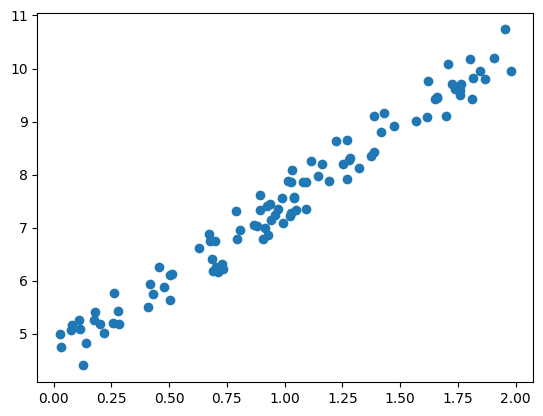

In [3]:
plt.scatter(x,y)

In [4]:
x_b=np.c_[np.ones((100,1)),x]
theta_best = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)

theta_best

array([[4.60053198],
       [2.89593301]])

In [5]:
x_new=np.array([[0],[2]])
x_new_b=np.c_[np.ones((2,1)),x_new]

In [6]:
y_predict=x_new_b.dot(theta_best)
y_predict

array([[ 4.60053198],
       [10.392398  ]])

(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(15.0))

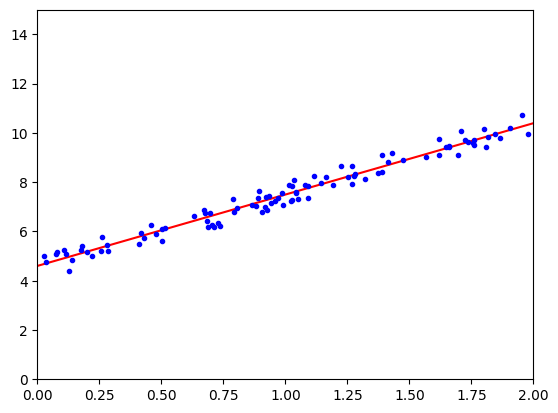

In [7]:
plt.plot(x_new,y_predict,"r-")
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lin_reg=LinearRegression()
lin_reg.fit(x,y)
lin_reg.intercept_,lin_reg.coef_

(array([4.60053198]), array([[2.89593301]]))

In [10]:
lin_reg.predict(x_new)

array([[ 4.60053198],
       [10.392398  ]])

In [11]:
eta=0.1
n_iterations=1000
m=1000
theta=np.random.randn(2,1)
for i in range(n_iterations):
  grad=2/m*x_b.T.dot(x_b.dot(theta)-y)
  theta-=eta*grad
theta

array([[4.51131874],
       [2.97390571]])

In [12]:
n_epochs = 50
t0, t1 = 5, 50 
def learning_schedule(t):
 return t0 / (t + t1)
theta = np.random.randn(2,1) 
for epoch in range(n_epochs):
 for i in range(m):
    random_index = np.random.randint(m)
    xi = x_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
    eta = learning_schedule(epoch * m + i)
    theta = theta - eta * gradients


In [13]:
theta

array([[4.64583196],
       [2.8578464 ]])

In [14]:
from sklearn.linear_model import SGDRegressor

In [15]:
sgd_reg=SGDRegressor(max_iter=1000,tol=1e-3,penalty=None,eta0=0.01)
sgd_reg.fit(x,y.ravel())
sgd_reg.intercept_,sgd_reg.coef_

(array([4.15083818]), array([3.28863891]))

In [16]:
m=100
x=6*np.random.randn(m,1)
y=0.5 * x**2 + x + 2 + np.random.randn(m, 1)


In [17]:
from sklearn.preprocessing import PolynomialFeatures

In [18]:
poly_feat=PolynomialFeatures(degree=2,include_bias=False)
x_poly = poly_feat.fit_transform(x)
x[0]

array([-4.06606255])

In [19]:
x_poly[0]

array([-4.06606255, 16.53286465])

In [20]:
lin_reg = LinearRegression()
lin_reg.fit(x_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.89634245]), array([[1.01077436, 0.50065861]]))

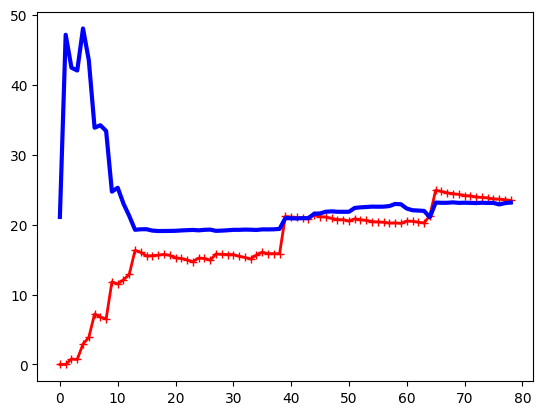

In [21]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_learning_curves(model, X, y):
 X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
 train_errors, val_errors = [], []
 for m in range(1, len(X_train)):
  model.fit(X_train[:m], y_train[:m])
  y_train_predict = model.predict(X_train[:m])
  y_val_predict = model.predict(X_val)
  train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
  val_errors.append(mean_squared_error(y_val, y_val_predict))
 plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
 plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
lin_reg=LinearRegression()
plot_learning_curves(lin_reg,x,y)


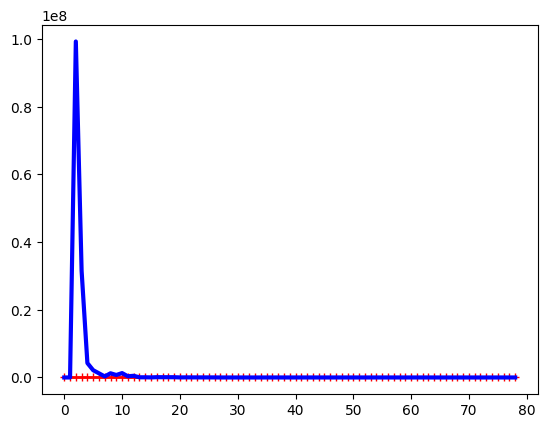

In [22]:
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
 ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
 ("lin_reg", LinearRegression()),
 ])
plot_learning_curves(polynomial_regression, x, y)

In [23]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")
ridge_reg.fit(x, y)
ridge_reg.predict([[1.5]])


array([24.32767728])

In [24]:
sgd_reg=SGDRegressor(penalty='l2')
sgd_reg.fit(x,y.ravel())
sgd_reg.predict([[1.5]])

array([23.68124705])